# Value-bootstrap trace: observations, actions, rewards + reward-rate, value, diff_reward, luck

Loads a trajectory saved by `train_treadmill_agent_jax_value_bootstrap.py` and plots, on a shared time
axis, the sensory observations, actions, rewards, and the quantities the objective uses:

- `rho = exp_filtered_reward_rate` — the running average reward rate;
- `V` — the critic value `V_t`;
- `diff_reward` — the (sparse) differential reward at reward steps;
- `luck = EMA(r - E[r])` — the filtered reward-prediction error ("recent luck") subtracted from the
  advantage. `E[r]` is the actor's single-step reward prediction, so this panel **needs the checkpoint
  weights** (everything else is read straight from the trajectory).

In [82]:
import os
# Force CPU before any jax import (the GPU is often full); harmless if jax isn't used.
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import sys, glob, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))          # code/  (agents, environments, ...)

## Model / trajectory

Point `EXP` at the run of interest. The loader grabs the latest saved trajectory — a training snapshot
(`results/<EXP>/trajectories/traj_*.pkl`) or an eval dump (`results/<EXP>/trajectories_*.pkl`).

In [83]:
# Locate the repo root (the directory that contains results/).
REPO = Path.cwd()
while not (REPO / 'results').exists() and REPO != REPO.parent:
    REPO = REPO.parent

EXP      = 'r_minus_rate_value_bootstrap_exp_gru_initial_prob_offset_v18'   # <- set to your run
TRAJ_IDX = 0                                                               # which saved env / episode

cands = (sorted(glob.glob(str(REPO / 'results' / EXP / 'trajectories' / 'traj_*.pkl')))
         + sorted(glob.glob(str(REPO / 'results' / EXP / 'trajectories_*.pkl'))))
assert cands, f'no trajectory pkl under results/{EXP}/ (train a run first, or fix EXP)'
TRAJ_PATH = cands[-1]
print('repo:', REPO)
print('trajectory:', os.path.relpath(TRAJ_PATH, REPO))

repo: /home/david.bell/work/favorably_connected_2
trajectory: results/r_minus_rate_value_bootstrap_exp_gru_initial_prob_offset_v18/trajectories/traj_000350.pkl


In [84]:
with open(TRAJ_PATH, 'rb') as f:
    traj = pickle.load(f)
d = traj[TRAJ_IDX] if isinstance(traj, list) else traj

obs_full     = np.asarray(d['observations'])             # (T, obs+act+1)
OBS          = obs_full.shape[1] - 3                     # minus action_onehot(2) + prev_reward(1)
obs          = obs_full[:, :OBS]                         # (T, OBS)  sensory part
actions      = np.asarray(d['actions'])                 # (T,)
rewards      = np.asarray(d['rewards'])                  # (T,)
rho          = np.asarray(d['exp_filtered_reward_rate']) # (T,)  E[r] used by the objective
V            = np.asarray(d['values'])                  # (T,)  critic value V_t
actor_hidden = np.asarray(d['actor_hidden'])            # (T, HID)  for the reward predictor / luck
T = rewards.shape[0]

In [85]:
# --- recent luck  L_t = EMA(r - E[r])  (needs the checkpoint weights) -----------------------------
# E[r] = single-timestep reward prediction from the ACTOR hidden state (predict_reward readout). L is
# its parallel EMA subtracted from the filtered reward -- a low-passed reward-prediction error read
# strictly from the past, with GLOBAL_REWARD_DECAY: "how lucky have I been recently" (the advantage
# baseline). Recomputed here exactly as in compute_a2c_loss.
import jax, jax.numpy as jnp
from flax.training import checkpoints
from agents.a2c_rnn_reward_pred_flax import A2CRNNFlax, init_network_and_params

HID, ACT, RNN = actor_hidden.shape[1], 2, 'GRU'
REWARD_PRED_HIDDEN, RPE_H, GLOBAL_REWARD_DECAY = 64, 20, 0.99      # match the training script
CKPT_DIR = os.path.abspath(str(REPO / 'checkpoints' / EXP))
assert os.path.exists(os.path.join(CKPT_DIR, 'checkpoint_0')), f'no checkpoint_0 under {CKPT_DIR}'

_, params0 = init_network_and_params(HID, ACT, OBS, RNN, 0.0, jax.random.key(0),
                                     reward_pred_hidden_size=REWARD_PRED_HIDDEN, reward_pred_horizon=RPE_H + 1)
params = checkpoints.restore_checkpoint(ckpt_dir=CKPT_DIR, target={'params': params0}, step=0)['params']
rnet = A2CRNNFlax(action_size=ACT, hidden_size=HID, unit_noise_std=0.0, rnn_type=RNN, obs_size=OBS,
                  reward_pred_hidden_size=REWARD_PRED_HIDDEN, reward_pred_horizon=RPE_H + 1)
r_pred = np.asarray(rnet.apply(params, jnp.asarray(actor_hidden),
                               method=A2CRNNFlax.predict_reward))[:, 0]       # (T,)  E[r_t | F_{t-1}]

# luck: past-only EMA of the reward-prediction error (emit the value BEFORE folding in the current step)
innov = rewards - r_pred
luck = np.empty(T); c = 0.0
for tt in range(T):
    luck[tt] = c
    c = GLOBAL_REWARD_DECAY * c + (1.0 - GLOBAL_REWARD_DECAY) * innov[tt]

print(f'r_pred [{r_pred.min():.4f}, {r_pred.max():.4f}]  |  luck [{luck.min():.4f}, {luck.max():.4f}]')

# diff_reward, recomputed exactly as compute_a2c_loss:  where(r > 0, r - rho, 0)
diff_reward = np.where(rewards > 0, rewards + 0.75 * luck / (1 - 0.99), 0.0)   # (T,)  sparse (nonzero at reward steps)


r_pred [-0.2251, 0.6947]  |  luck [-0.0333, 0.0248]


## Trace

Set `T0`/`T1` to the window to view (the full trajectory is usually too long to read at once).

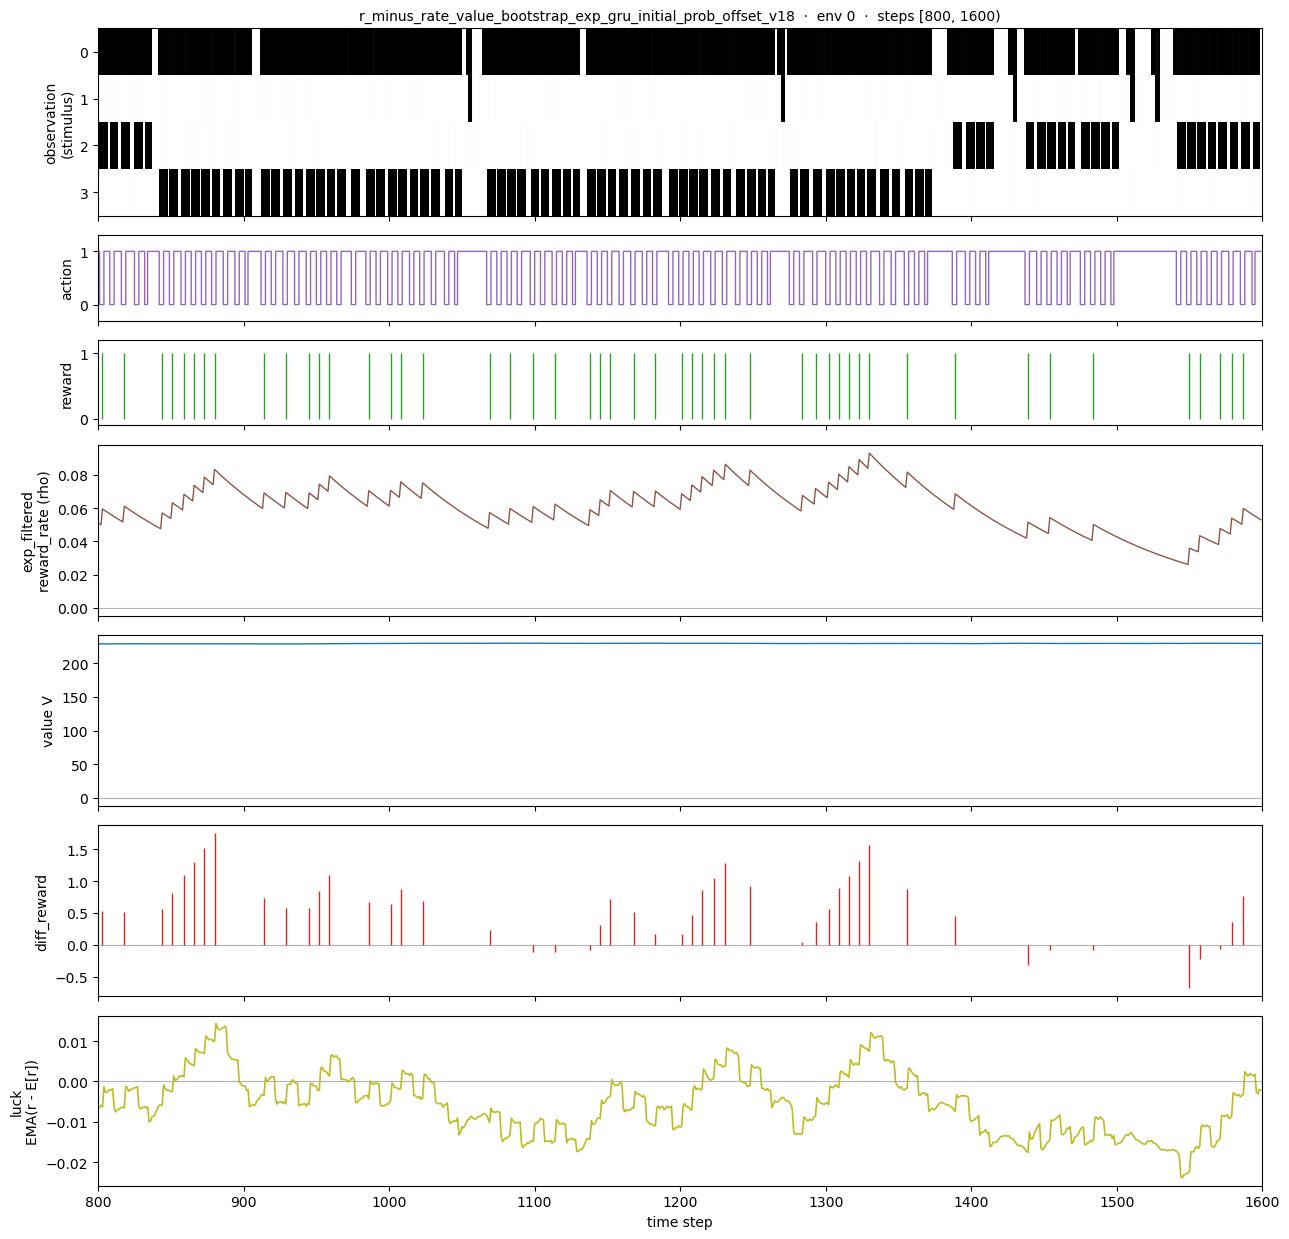

In [86]:
T0, T1 = 800, min(1600, T)          # time window to plot
t = np.arange(T0, T1)

fig, ax = plt.subplots(7, 1, sharex=True, figsize=(13, 12.5),
                       gridspec_kw={'height_ratios': [1.1, 0.5, 0.5, 1.0, 1.0, 1.0, 1.0]})

# 1) observations (stimulus x time)
ax[0].imshow(obs[T0:T1].T, aspect='auto', cmap='Greys', vmin=0, vmax=1,
             extent=[T0, T1, OBS - 0.5, -0.5], interpolation='nearest')
ax[0].set_yticks(range(OBS)); ax[0].set_ylabel('observation\n(stimulus)')

# 2) action
ax[1].step(t, actions[T0:T1], where='post', color='tab:purple', lw=1)
ax[1].set_yticks([0, 1]); ax[1].set_ylim(-0.3, 1.3); ax[1].set_ylabel('action')

# 3) reward (spikes)
ax[2].vlines(t[rewards[T0:T1] > 0], 0, 1, color='tab:green', lw=1)
ax[2].set_yticks([0, 1]); ax[2].set_ylim(-0.1, 1.2); ax[2].set_ylabel('reward')

# 4) exp_filtered_reward_rate (rho = E[r])
ax[3].axhline(0, color='0.7', lw=0.8)
ax[3].plot(t, rho[T0:T1], color='tab:brown', lw=1)
ax[3].set_ylabel('exp_filtered\nreward_rate (rho)')

# 5) value V
ax[4].axhline(0, color='0.7', lw=0.8)
ax[4].plot(t, V[T0:T1], color='tab:blue', lw=1)
ax[4].set_ylabel('value V')

# 6) diff_reward at reward steps (sparse)
ax[5].axhline(0, color='0.7', lw=0.8)
mk = rewards[T0:T1] > 0
ax[5].vlines(t[mk], 0, diff_reward[T0:T1][mk], color='tab:red', lw=1)
ax[5].set_ylabel('diff_reward')

# 7) recent luck  L = EMA(r - E[r])   (advantage baseline)
ax[6].axhline(0, color='0.7', lw=0.8)
ax[6].plot(t, luck[T0:T1], color='tab:olive', lw=1.2)
ax[6].set_ylabel('luck\nEMA(r - E[r])'); ax[6].set_xlabel('time step')

ax[0].set_title(f'{EXP}  ·  env {TRAJ_IDX}  ·  steps [{T0}, {T1})', fontsize=10)
plt.tight_layout()
plt.show()